In [19]:
# Times Square Parameters
day_obs = 20260428

In [45]:
import matplotlib.pyplot as plt
from lsst.daf.butler import Butler
from astropy.table import vstack
%matplotlib inline

## Available Overnight Collections

In [21]:
butler = Butler('embargo', instrument='LSSTCam')

In [24]:
print(f'Available AOS Collections processed overnight at USDF for day_obs: {day_obs}')
available_collections = butler.registry.queryCollections(f'u/brycek/aos_cwfs_nightly/wep_v16_9_0/donut_viz_v3_6_1/{day_obs}')
print(available_collections)

Available AOS Collections processed overnight at USDF for day_obs: 20260428
['u/brycek/aos_cwfs_nightly/wep_v16_9_0/donut_viz_v3_6_1/20260428']


## Overnight Results Comparison

In [42]:
agg_visit_dict = dict()
for coll_name in available_collections:
    aggregate_tables = butler.query_datasets('aggregateAOSVisitTableAvg', collections=coll_name)
    all_visits = None
    for agg_table in aggregate_tables:
        visit_table = butler.get(agg_table)
        visit_table['visit'] = visit_table.meta['visit']
        if all_visits is None:
            all_visits = visit_table.copy()
        else:
            all_visits = vstack([all_visits, visit_table], metadata_conflicts='silent')
    agg_visit_dict[coll_name] = all_visits

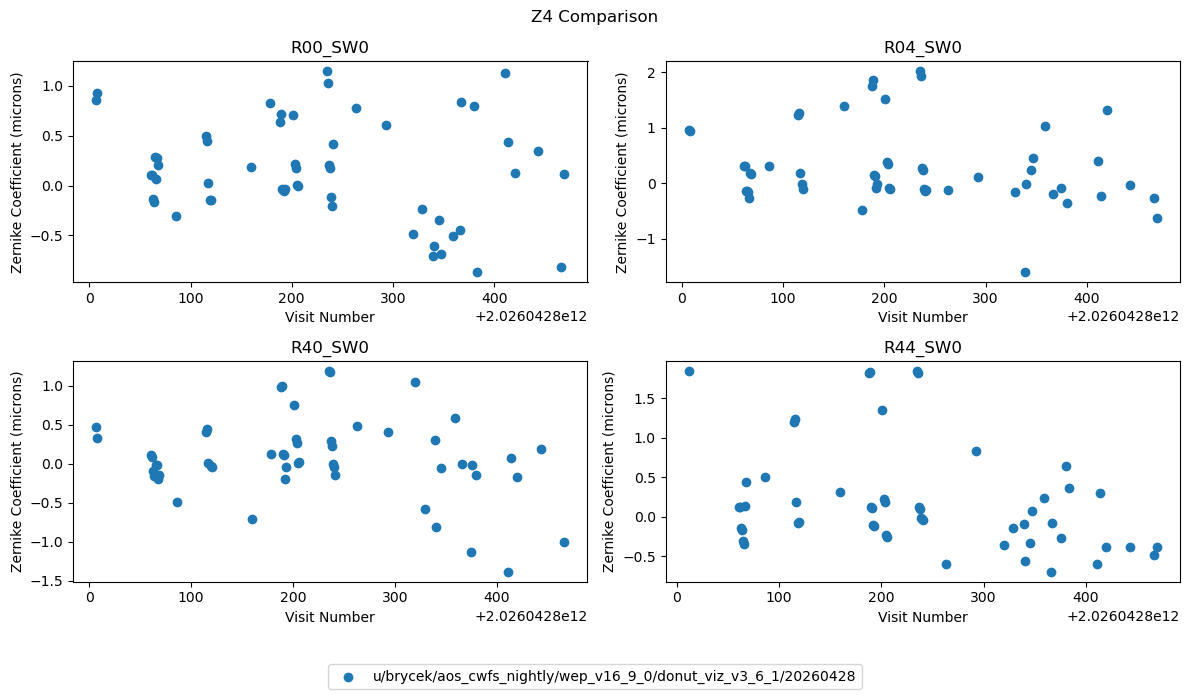

In [60]:
fig = plt.figure(figsize=(12, 7))
det_names = ['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0']
zern_idx = 0
for i in range(4):
    ax = fig.add_subplot(2,2,i+1)
    for coll_name in available_collections:
        det_table = agg_visit_dict[coll_name][agg_visit_dict[coll_name]['detector'] == det_names[i]]
        z_vals = det_table['zk_deviation_CCS'][:, zern_idx]
        ax.scatter(det_table['visit'], z_vals, label=coll_name)
    ax.set_xlabel('Visit Number')
    ax.set_ylabel('Zernike Coefficient (microns)')
    ax.set_title(det_names[i])

plt.suptitle(f'Z{det_table.meta["nollIndices"][zern_idx]} Comparison')

# Grab handles/labels from the last axes and place a single legend below the figure
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0),
           ncol=len(available_collections), frameon=True)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # leave room at the bottom for the legend